# 실험 3 — 지갑 4종·19장 확장 Retrieval 실험

## 목적
지갑 종류와 후보 수를 늘려 SigLIP2와 DINOv2의 Retrieval 성능을 보다 체계적으로 평가한다.

## 데이터
- 민준 지갑 5장
- 병주 지갑 5장
- 성현 지갑 5장
- 현두 지갑 4장
- 총 19장

## 평가
- 민준지갑_01 단일 Query Retrieval
- 모든 이미지를 Query로 사용한 Top-1 Accuracy
- Recall@K 평가 함수

> 이미지 19장을 먼저 `/content`로 Upload to Colab 한 뒤 실행한다.


## 0. GPU 및 실행 환경 확인


In [1]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


## 1. 필요한 라이브러리 설치


In [2]:
%pip install -q -U transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 121.1 MB/s eta 0:00:0000:0100:01


## 2. Colab 업로드 파일 확인


In [3]:
!ls -lh /content

total 72M
-rw-r--r-- 1 root root 4.0M Aug 26 08:03 병주지갑_01.jpg
-rw-r--r-- 1 root root 2.8M Aug 26 08:02 민준지갑_01.jpg
-rw-r--r-- 1 root root 4.2M Aug 26 08:06 현두지갑_01.jpg
-rw-r--r-- 1 root root 3.3M Aug 26 08:04 성현지갑_01.jpg
-rw-r--r-- 1 root root 4.1M Aug 26 08:06 현두지갑_02.jpg
-rw-r--r-- 1 root root 3.5M Aug 26 08:04 성현지갑_02.jpg
-rw-r--r-- 1 root root 3.2M Aug 26 08:02 민준지갑_02.jpg
-rw-r--r-- 1 root root 4.3M Aug 26 08:03 병주지갑_02.jpg
-rw-r--r-- 1 root root 4.0M Aug 26 08:03 병주지갑_03.jpg
-rw-r--r-- 1 root root 4.3M Aug 26 08:05 성현지갑_03.jpg
-rw-r--r-- 1 root root 3.8M Aug 26 08:02 민준지갑_03.jpg
-rw-r--r-- 1 root root 4.1M Aug 26 08:06 현두지갑_03.jpg
-rw-r--r-- 1 root root 3.2M Aug 26 08:02 민준지갑_04.jpg
-rw-r--r-- 1 root root 4.2M Aug 26 08:06 현두지갑_04.jpg
-rw-r--r-- 1 root root 4.5M Aug 26 08:03 병주지갑_04.jpg
-rw-r--r-- 1 root root 4.6M Aug 26 08:05 성현지갑_04.jpg
-rw-r--r-- 1 root root 2.9M Aug 26 08:03 민준지갑_05.jpg
-rw-r--r-- 1 root root 4.3M Aug 26 08:05 성현지갑_05.jpg
-rw-r--r-- 1 root root 3.5M Aug 26 0

## 3. `/content`에서 전체 지갑 이미지 자동 탐색


In [4]:
import glob
import os
from PIL import Image

image_files = sorted(
    glob.glob("/content/*지갑_*.jpg")
)

print("총 이미지 수:", len(image_files))

for path in image_files:
    print(os.path.basename(path))

총 이미지 수: 19
민준지갑_01.jpg
민준지갑_02.jpg
민준지갑_03.jpg
민준지갑_04.jpg
민준지갑_05.jpg
병주지갑_01.jpg
병주지갑_02.jpg
병주지갑_03.jpg
병주지갑_04.jpg
병주지갑_05.jpg
성현지갑_01.jpg
성현지갑_02.jpg
성현지갑_03.jpg
성현지갑_04.jpg
성현지갑_05.jpg
현두지갑_01.jpg
현두지갑_02.jpg
현두지갑_03.jpg
현두지갑_04.jpg


## 4. 전체 이미지 로드


In [5]:
all_images = [
    Image.open(path).convert("RGB")
    for path in image_files
]

print("로드된 이미지:", len(all_images))

로드된 이미지: 19


## 5. 파일명으로 Label 생성


In [6]:
labels = [
    os.path.splitext(
        os.path.basename(path)
    )[0]
    for path in image_files
]

for i, label in enumerate(labels):
    print(i, label)

0 민준지갑_01
1 민준지갑_02
2 민준지갑_03
3 민준지갑_04
4 민준지갑_05
5 병주지갑_01
6 병주지갑_02
7 병주지갑_03
8 병주지갑_04
9 병주지갑_05
10 성현지갑_01
11 성현지갑_02
12 성현지갑_03
13 성현지갑_04
14 성현지갑_05
15 현두지갑_01
16 현두지갑_02
17 현두지갑_03
18 현두지갑_04


## 6. 전체 19장 시각화


/tmp/ipykernel_2485/2442795900.py:23: UserWarning: Glyph 48124 (\N{HANGUL SYLLABLE MIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2485/2442795900.py:23: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2485/2442795900.py:23: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2485/2442795900.py:23: UserWarning: Glyph 44049 (\N{HANGUL SYLLABLE GAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2485/2442795900.py:23: UserWarning: Glyph 48337 (\N{HANGUL SYLLABLE BYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2485/2442795900.py:23: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2485/2442795900.py:23: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tigh

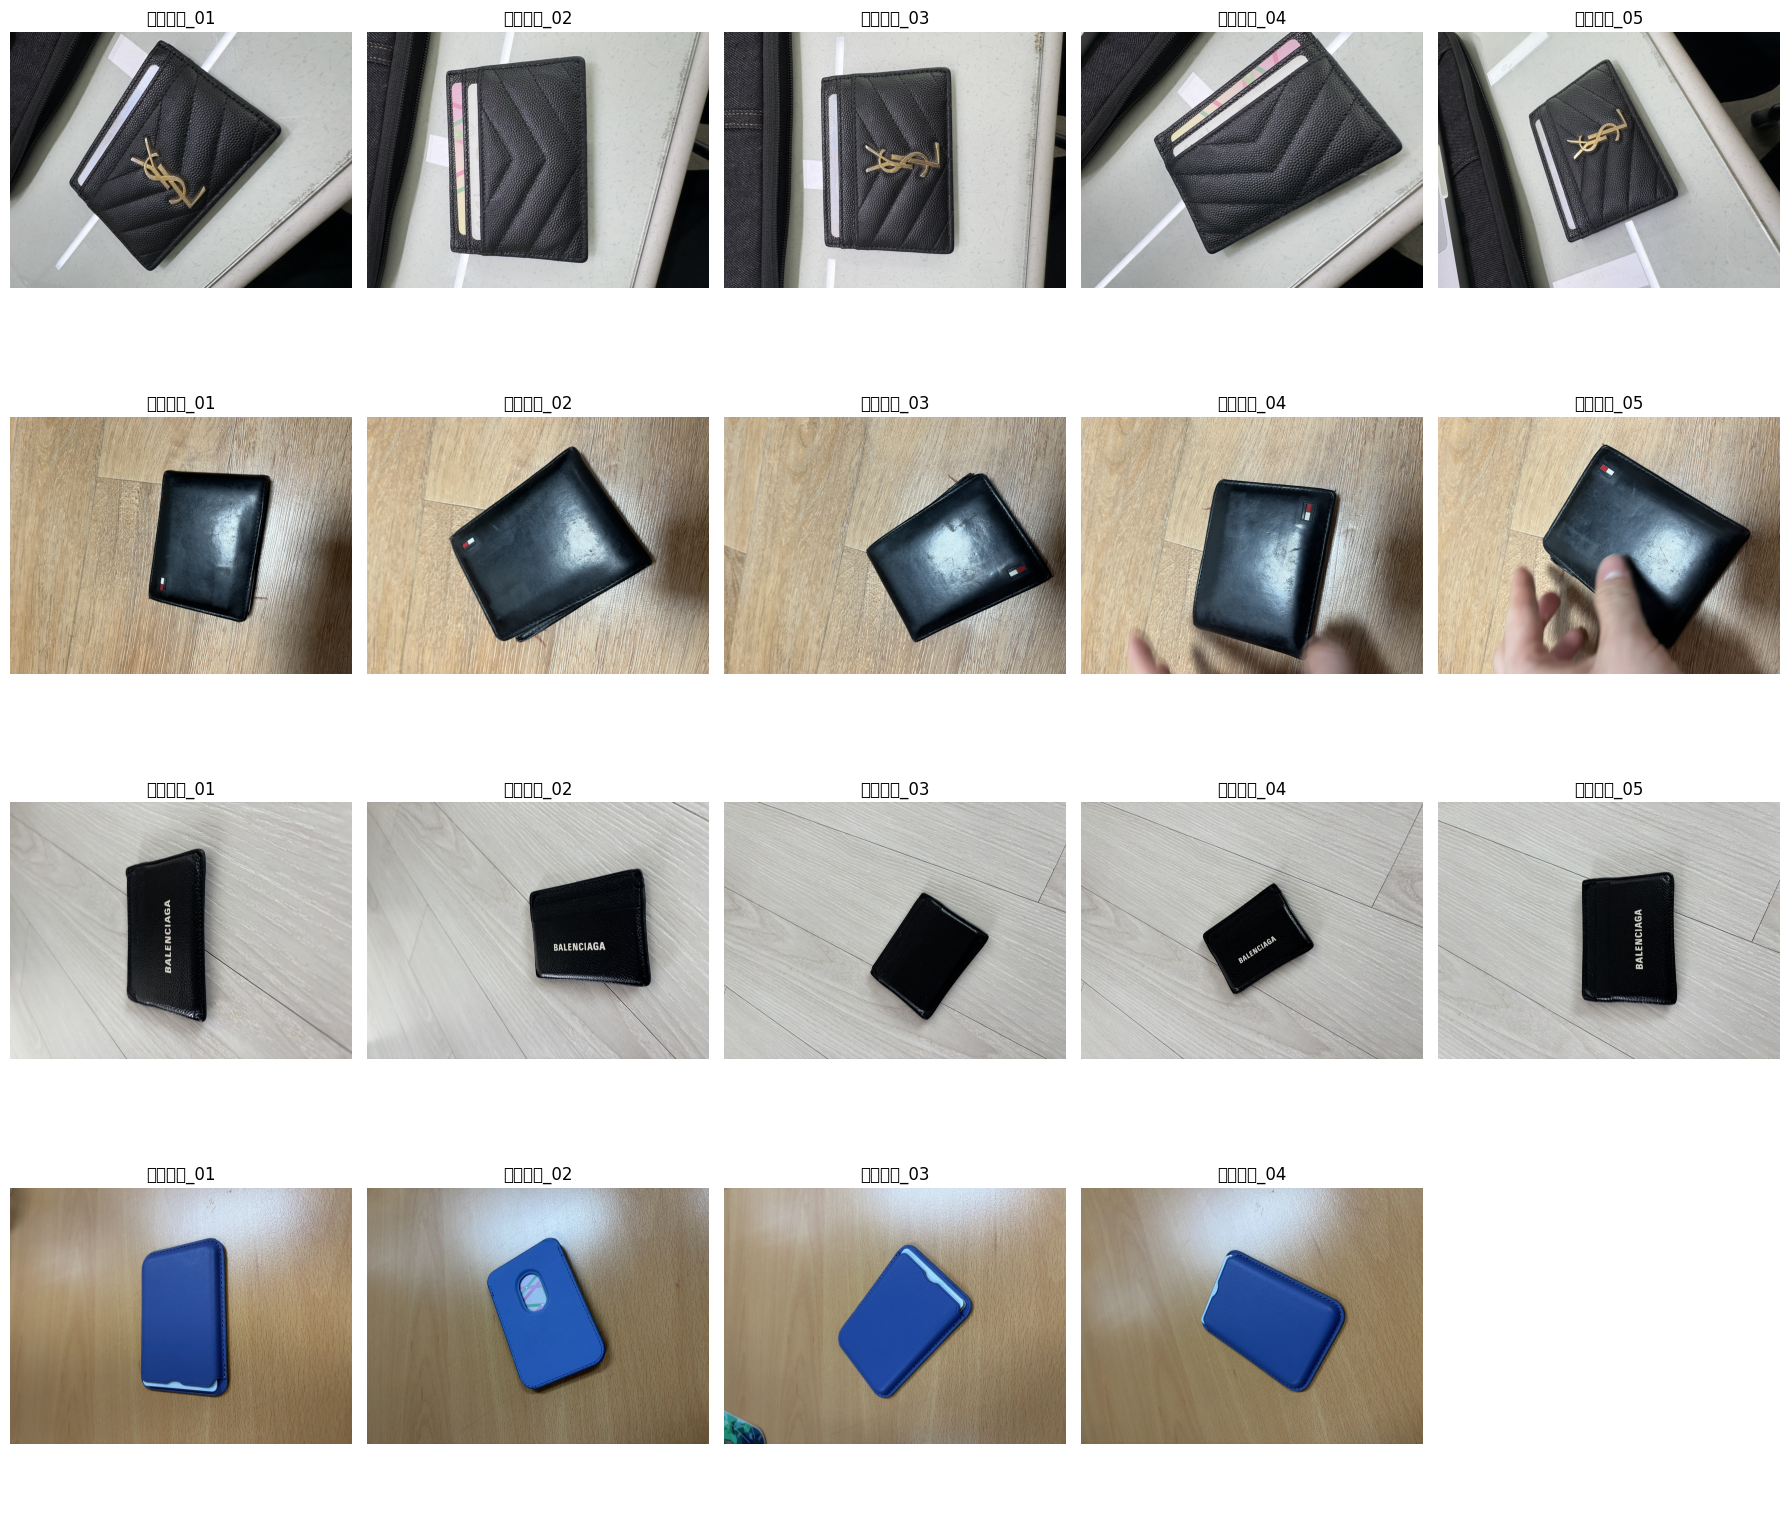

In [7]:
import matplotlib.pyplot as plt
import math

cols = 5
rows = math.ceil(len(all_images) / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(18, rows * 4)
)

axes = axes.flatten()

for i, image in enumerate(all_images):
    axes[i].imshow(image)
    axes[i].set_title(labels[i])
    axes[i].axis("off")

for i in range(len(all_images), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 7. SigLIP2 모델 로드


In [8]:
import torch
import torch.nn.functional as F
from transformers import AutoModel, AutoProcessor

device = "cuda" if torch.cuda.is_available() else "cpu"

siglip_model_id = "google/siglip2-base-patch16-224"

siglip_processor = AutoProcessor.from_pretrained(
    siglip_model_id
)

siglip_model = AutoModel.from_pretrained(
    siglip_model_id,
    torch_dtype=torch.float16
).to(device)

siglip_model.eval()

print("SigLIP2 loaded!")
print("Device:", device)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


preprocessor_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/253 [00:00<?, ?B/s]

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


tokenizer_config.json:   0%|          | 0.00/47.2k [00:00<?, ?B/s]

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.50GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

SigLIP2 loaded!
Device: cuda


## 8. SigLIP2 임베딩 함수 정의


In [9]:
def get_siglip_embedding(image):
    inputs = siglip_processor(
        images=image,
        return_tensors="pt"
    )

    inputs = {
        k: (
            v.to(device, dtype=torch.float16)
            if v.is_floating_point()
            else v.to(device)
        )
        for k, v in inputs.items()
    }

    with torch.no_grad():
        outputs = siglip_model.get_image_features(**inputs)

    embedding = outputs.pooler_output

    embedding = F.normalize(
        embedding,
        p=2,
        dim=-1
    )

    return embedding

## 9. 전체 데이터 SigLIP2 임베딩 생성


In [10]:
siglip_all_embeddings = torch.cat(
    [
        get_siglip_embedding(image)
        for image in all_images
    ],
    dim=0
)

print(
    "SigLIP2 embedding shape:",
    siglip_all_embeddings.shape
)

SigLIP2 embedding shape: torch.Size([19, 768])


## 10. DINOv2 모델 로드


In [11]:
from transformers import AutoImageProcessor, AutoModel

dino_model_id = "facebook/dinov2-base"

dino_processor = AutoImageProcessor.from_pretrained(
    dino_model_id
)

dino_model = AutoModel.from_pretrained(
    dino_model_id
).to(device)

dino_model.eval()

print("DINOv2 loaded!")

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2 loaded!


## 11. DINOv2 임베딩 함수 정의


In [12]:
def get_dino_embedding(image):
    inputs = dino_processor(
        images=image,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    with torch.no_grad():
        outputs = dino_model(**inputs)

    embedding = outputs.pooler_output

    embedding = F.normalize(
        embedding,
        p=2,
        dim=-1
    )

    return embedding

## 12. 전체 데이터 DINOv2 임베딩 생성


In [13]:
dino_all_embeddings = torch.cat(
    [
        get_dino_embedding(image)
        for image in all_images
    ],
    dim=0
)

print(
    "DINOv2 embedding shape:",
    dino_all_embeddings.shape
)

DINOv2 embedding shape: torch.Size([19, 768])


## 13. Label 확인


In [14]:
import os

labels = [
    os.path.splitext(
        os.path.basename(path)
    )[0]
    for path in image_files
]

print("총 이미지 수:", len(labels))

for i, label in enumerate(labels):
    print(i, label)

총 이미지 수: 19
0 민준지갑_01
1 민준지갑_02
2 민준지갑_03
3 민준지갑_04
4 민준지갑_05
5 병주지갑_01
6 병주지갑_02
7 병주지갑_03
8 병주지갑_04
9 병주지갑_05
10 성현지갑_01
11 성현지갑_02
12 성현지갑_03
13 성현지갑_04
14 성현지갑_05
15 현두지갑_01
16 현두지갑_02
17 현두지갑_03
18 현두지갑_04


## 14. 파일명에서 지갑 소유자 추출


In [15]:
def get_owner(label):
    return label.split("지갑_")[0]


for label in labels:
    print(label, "→", get_owner(label))

민준지갑_01 → 민준
민준지갑_02 → 민준
민준지갑_03 → 민준
민준지갑_04 → 민준
민준지갑_05 → 민준
병주지갑_01 → 병주
병주지갑_02 → 병주
병주지갑_03 → 병주
병주지갑_04 → 병주
병주지갑_05 → 병주
성현지갑_01 → 성현
성현지갑_02 → 성현
성현지갑_03 → 성현
성현지갑_04 → 성현
성현지갑_05 → 성현
현두지갑_01 → 현두
현두지갑_02 → 현두
현두지갑_03 → 현두
현두지갑_04 → 현두


## 15. 정답 여부를 포함한 Retrieval Ranking 함수


In [16]:
import torch.nn.functional as F

def rank_candidates(query_index, embeddings, labels):
    query_embedding = embeddings[
        query_index:query_index + 1
    ]

    query_owner = get_owner(
        labels[query_index]
    )

    results = []

    for i in range(len(labels)):

        # 자기 자신 제외
        if i == query_index:
            continue

        score = F.cosine_similarity(
            query_embedding,
            embeddings[i:i+1]
        ).item()

        results.append({
            "index": i,
            "label": labels[i],
            "owner": get_owner(labels[i]),
            "score": score,
            "correct": get_owner(labels[i]) == query_owner
        })

    results.sort(
        key=lambda x: x["score"],
        reverse=True
    )

    return results

## 16. 단일 Query 검증 — 민준지갑_01

먼저 민준지갑_01을 Query로 사용하여 18개 후보의 순위를 확인한다.


In [17]:
query_index = labels.index("민준지갑_01")

siglip_results = rank_candidates(
    query_index,
    siglip_all_embeddings,
    labels
)

dino_results = rank_candidates(
    query_index,
    dino_all_embeddings,
    labels
)

In [18]:
print("===== Query: 민준지갑_01 =====")

print("\n===== SigLIP2 =====")

for rank, result in enumerate(siglip_results, start=1):
    mark = "✅" if result["correct"] else "❌"

    print(
        f"{rank:2d}위 | "
        f"{result['label']:<12} | "
        f"{result['score']:.4f} | {mark}"
    )


print("\n===== DINOv2 =====")

for rank, result in enumerate(dino_results, start=1):
    mark = "✅" if result["correct"] else "❌"

    print(
        f"{rank:2d}위 | "
        f"{result['label']:<12} | "
        f"{result['score']:.4f} | {mark}"
    )

===== Query: 민준지갑_01 =====

===== SigLIP2 =====
 1위 | 민준지갑_03      | 0.9604 | ✅
 2위 | 민준지갑_05      | 0.9463 | ✅
 3위 | 민준지갑_04      | 0.8799 | ✅
 4위 | 민준지갑_02      | 0.8608 | ✅
 5위 | 성현지갑_02      | 0.8120 | ❌
 6위 | 성현지갑_01      | 0.7695 | ❌
 7위 | 성현지갑_04      | 0.7603 | ❌
 8위 | 성현지갑_05      | 0.7598 | ❌
 9위 | 병주지갑_02      | 0.7188 | ❌
10위 | 병주지갑_03      | 0.6895 | ❌
11위 | 병주지갑_04      | 0.6831 | ❌
12위 | 병주지갑_05      | 0.6802 | ❌
13위 | 병주지갑_01      | 0.6772 | ❌
14위 | 성현지갑_03      | 0.6558 | ❌
15위 | 현두지갑_04      | 0.6509 | ❌
16위 | 현두지갑_01      | 0.6348 | ❌
17위 | 현두지갑_03      | 0.6128 | ❌
18위 | 현두지갑_02      | 0.5859 | ❌

===== DINOv2 =====
 1위 | 민준지갑_05      | 0.8665 | ✅
 2위 | 민준지갑_04      | 0.8009 | ✅
 3위 | 민준지갑_03      | 0.7938 | ✅
 4위 | 민준지갑_02      | 0.7782 | ✅
 5위 | 병주지갑_04      | 0.6339 | ❌
 6위 | 병주지갑_01      | 0.6072 | ❌
 7위 | 병주지갑_02      | 0.6051 | ❌
 8위 | 병주지갑_05      | 0.6028 | ❌
 9위 | 성현지갑_01      | 0.5954 | ❌
10위 | 병주지갑_03      | 0.5848 | ❌
11위 | 성현지갑_02      | 0.5391 | ❌
12위 

## 17. 모든 Query 기준 Top-1 Accuracy

각 이미지가 한 번씩 Query가 되었을 때 검색 결과 1위가 동일한 실제 지갑인지 평가한다.


In [19]:
def top1_accuracy(embeddings, labels):
    correct = 0

    for i in range(len(labels)):
        results = rank_candidates(
            i,
            embeddings,
            labels
        )

        if results[0]["correct"]:
            correct += 1

    return correct / len(labels)

In [20]:
siglip_top1 = top1_accuracy(
    siglip_all_embeddings,
    labels
)

dino_top1 = top1_accuracy(
    dino_all_embeddings,
    labels
)

print(
    f"SigLIP2 Top-1 Accuracy : "
    f"{siglip_top1:.4f}"
)

print(
    f"DINOv2  Top-1 Accuracy : "
    f"{dino_top1:.4f}"
)

SigLIP2 Top-1 Accuracy : 0.9474
DINOv2  Top-1 Accuracy : 1.0000


## 18. Recall@K 평가 함수

Query 자기 자신을 제외한 동일 소유자 지갑 사진들을 Positive로 정의하고 Recall@K를 계산한다.

현재 원본 실험 기록은 이 함수 정의 단계까지 진행되어 있다.


In [21]:
def recall_at_k(
    query_index,
    embeddings,
    labels,
    k
):
    query_owner = get_owner(
        labels[query_index]
    )

    results = rank_candidates(
        query_index,
        embeddings,
        labels
    )

    # 자기 자신을 제외한 동일 지갑 사진 수
    total_positive = sum(
        1
        for i, label in enumerate(labels)
        if (
            i != query_index
            and get_owner(label) == query_owner
        )
    )

    top_k = results[:k]

    retrieved_positive = sum(
        1
        for result in top_k
        if result["correct"]
    )

    return retrieved_positive / total_positive

## 실험 3 현재 진행 위치

현재까지 완료:
- 4종·19장 데이터 자동 탐색
- SigLIP2 / DINOv2 전체 임베딩 생성
- 민준지갑_01 Retrieval
- 전체 Query Top-1 Accuracy
- Recall@K 함수 정의

다음 단계:
- 모든 Query에 대한 Mean Recall@1 / @3 / @5
- Hard Negative 분석
- Positive / Negative Margin 분석


In [22]:
import numpy as np

def evaluate_recall(
    embeddings,
    labels,
    model_name
):
    recall_results = {
        1: [],
        3: [],
        5: []
    }

    for query_index in range(len(labels)):

        for k in recall_results.keys():

            recall = recall_at_k(
                query_index,
                embeddings,
                labels,
                k
            )

            recall_results[k].append(recall)

    print(f"===== {model_name} Recall =====")

    for k, values in recall_results.items():

        mean_recall = np.mean(values)

        print(
            f"Mean Recall@{k}: "
            f"{mean_recall:.4f}"
        )

    return recall_results

In [23]:
siglip_recalls = evaluate_recall(
    siglip_all_embeddings,
    labels,
    "SigLIP2"
)

print()

dino_recalls = evaluate_recall(
    dino_all_embeddings,
    labels,
    "DINOv2"
)

===== SigLIP2 Recall =====
Mean Recall@1: 0.2544
Mean Recall@3: 0.7632
Mean Recall@5: 0.9079

===== DINOv2 Recall =====
Mean Recall@1: 0.2675
Mean Recall@3: 0.7237
Mean Recall@5: 0.9167


In [24]:
import pandas as pd

rows = []

for i in range(len(labels)):

    rows.append({
        "query": labels[i],
        "owner": get_owner(labels[i]),

        "siglip_R1": recall_at_k(
            i,
            siglip_all_embeddings,
            labels,
            1
        ),

        "siglip_R3": recall_at_k(
            i,
            siglip_all_embeddings,
            labels,
            3
        ),

        "siglip_R5": recall_at_k(
            i,
            siglip_all_embeddings,
            labels,
            5
        ),

        "dino_R1": recall_at_k(
            i,
            dino_all_embeddings,
            labels,
            1
        ),

        "dino_R3": recall_at_k(
            i,
            dino_all_embeddings,
            labels,
            3
        ),

        "dino_R5": recall_at_k(
            i,
            dino_all_embeddings,
            labels,
            5
        )
    })


recall_df = pd.DataFrame(rows)

display(
    recall_df.round(4)
)

,query,owner,siglip_R1,siglip_R3,siglip_R5,dino_R1,dino_R3,dino_R5
0,민준지갑_01,민준,0.2500,0.75,1.00,0.2500,0.7500,1.0000
1,민준지갑_02,민준,0.2500,0.75,1.00,0.2500,0.7500,1.0000
2,민준지갑_03,민준,0.2500,0.75,1.00,0.2500,0.7500,1.0000
3,민준지갑_04,민준,0.2500,0.75,1.00,0.2500,0.7500,1.0000
4,민준지갑_05,민준,0.2500,0.75,1.00,0.2500,0.7500,1.0000
5,병주지갑_01,병주,0.2500,0.75,1.00,0.2500,0.7500,1.0000
6,병주지갑_02,병주,0.2500,0.75,1.00,0.2500,0.7500,1.0000
7,병주지갑_03,병주,0.2500,0.75,1.00,0.2500,0.7500,1.0000
8,병주지갑_04,병주,0.2500,0.75,1.00,0.2500,0.7500,1.0000
9,병주지갑_05,병주,0.2500,0.75,1.00,0.2500,0.7500,1.0000


In [25]:
def find_top1_failures(
    embeddings,
    labels,
    model_name
):

    failures = []

    for i in range(len(labels)):

        results = rank_candidates(
            i,
            embeddings,
            labels
        )

        top1 = results[0]

        if not top1["correct"]:

            failures.append({
                "query": labels[i],
                "predicted": top1["label"],
                "score": top1["score"]
            })

    print(
        f"===== {model_name} "
        f"Top-1 Failure ====="
    )

    if len(failures) == 0:

        print(
            "Top-1 실패 없음 ✅"
        )

    else:

        for failure in failures:

            print(
                f"Query: {failure['query']}"
            )

            print(
                f"잘못 선택한 후보: "
                f"{failure['predicted']}"
            )

            print(
                f"Similarity: "
                f"{failure['score']:.4f}"
            )

            print("-" * 40)

    return failures

In [26]:
siglip_failures = find_top1_failures(
    siglip_all_embeddings,
    labels,
    "SigLIP2"
)

print()

dino_failures = find_top1_failures(
    dino_all_embeddings,
    labels,
    "DINOv2"
)

===== SigLIP2 Top-1 Failure =====
Query: 성현지갑_03
잘못 선택한 후보: 현두지갑_01
Similarity: 0.8467
----------------------------------------

===== DINOv2 Top-1 Failure =====
Top-1 실패 없음 ✅


In [27]:
def find_hardest_negative(
    query_index,
    embeddings,
    labels
):

    results = rank_candidates(
        query_index,
        embeddings,
        labels
    )

    for result in results:

        if not result["correct"]:

            return result

In [28]:
print(
    "===== SigLIP2 Hardest Negative ====="
)

for i in range(len(labels)):

    negative = find_hardest_negative(
        i,
        siglip_all_embeddings,
        labels
    )

    print(
        f"{labels[i]:<12}"
        f" → "
        f"{negative['label']:<12}"
        f" | "
        f"{negative['score']:.4f}"
    )

===== SigLIP2 Hardest Negative =====
민준지갑_01      → 성현지갑_02      | 0.8120
민준지갑_02      → 성현지갑_02      | 0.7686
민준지갑_03      → 성현지갑_02      | 0.8130
민준지갑_04      → 성현지갑_02      | 0.8052
민준지갑_05      → 성현지갑_02      | 0.7920
병주지갑_01      → 성현지갑_03      | 0.8057
병주지갑_02      → 성현지갑_03      | 0.7974
병주지갑_03      → 성현지갑_03      | 0.7808
병주지갑_04      → 성현지갑_03      | 0.7788
병주지갑_05      → 성현지갑_03      | 0.8120
성현지갑_01      → 민준지갑_04      | 0.7817
성현지갑_02      → 민준지갑_03      | 0.8130
성현지갑_03      → 현두지갑_01      | 0.8467
성현지갑_04      → 병주지갑_02      | 0.7881
성현지갑_05      → 병주지갑_02      | 0.7803
현두지갑_01      → 성현지갑_03      | 0.8467
현두지갑_02      → 성현지갑_03      | 0.8115
현두지갑_03      → 성현지갑_03      | 0.8452
현두지갑_04      → 성현지갑_03      | 0.8398


In [29]:
print(
    "===== DINOv2 Hardest Negative ====="
)

for i in range(len(labels)):

    negative = find_hardest_negative(
        i,
        dino_all_embeddings,
        labels
    )

    print(
        f"{labels[i]:<12}"
        f" → "
        f"{negative['label']:<12}"
        f" | "
        f"{negative['score']:.4f}"
    )

===== DINOv2 Hardest Negative =====
민준지갑_01      → 병주지갑_04      | 0.6339
민준지갑_02      → 병주지갑_04      | 0.6171
민준지갑_03      → 병주지갑_04      | 0.6071
민준지갑_04      → 병주지갑_04      | 0.6293
민준지갑_05      → 병주지갑_01      | 0.6061
병주지갑_01      → 성현지갑_05      | 0.7301
병주지갑_02      → 성현지갑_05      | 0.6766
병주지갑_03      → 성현지갑_05      | 0.6612
병주지갑_04      → 현두지갑_04      | 0.6834
병주지갑_05      → 성현지갑_01      | 0.6815
성현지갑_01      → 병주지갑_01      | 0.7011
성현지갑_02      → 병주지갑_01      | 0.6008
성현지갑_03      → 병주지갑_01      | 0.5625
성현지갑_04      → 병주지갑_01      | 0.6032
성현지갑_05      → 병주지갑_01      | 0.7301
현두지갑_01      → 병주지갑_04      | 0.6369
현두지갑_02      → 병주지갑_04      | 0.4747
현두지갑_03      → 병주지갑_04      | 0.6522
현두지갑_04      → 병주지갑_04      | 0.6834


In [30]:
def calculate_separation_margin(
    query_index,
    embeddings,
    labels
):

    results = rank_candidates(
        query_index,
        embeddings,
        labels
    )

    positive_scores = [
        result["score"]
        for result in results
        if result["correct"]
    ]

    negative_scores = [
        result["score"]
        for result in results
        if not result["correct"]
    ]

    min_positive = min(
        positive_scores
    )

    max_negative = max(
        negative_scores
    )

    margin = (
        min_positive
        - max_negative
    )

    return (
        min_positive,
        max_negative,
        margin
    )

In [31]:
def evaluate_separation_margin(
    embeddings,
    labels,
    model_name
):

    margins = []

    print(
        f"===== {model_name} "
        f"Separation Margin ====="
    )

    for i in range(len(labels)):

        min_pos, max_neg, margin = (
            calculate_separation_margin(
                i,
                embeddings,
                labels
            )
        )

        margins.append(
            margin
        )

        mark = (
            "✅"
            if margin > 0
            else "⚠️"
        )

        print(
            f"{labels[i]:<12} | "
            f"정답 최저 {min_pos:.4f} | "
            f"오답 최고 {max_neg:.4f} | "
            f"Margin {margin:+.4f} "
            f"{mark}"
        )

    print()
    print(
        f"평균 Margin: "
        f"{np.mean(margins):.4f}"
    )

    print(
        f"최소 Margin: "
        f"{np.min(margins):.4f}"
    )

    return margins

In [32]:
siglip_margins = (
    evaluate_separation_margin(
        siglip_all_embeddings,
        labels,
        "SigLIP2"
    )
)

print()

dino_margins = (
    evaluate_separation_margin(
        dino_all_embeddings,
        labels,
        "DINOv2"
    )
)

===== SigLIP2 Separation Margin =====
민준지갑_01      | 정답 최저 0.8608 | 오답 최고 0.8120 | Margin +0.0488 ✅
민준지갑_02      | 정답 최저 0.8608 | 오답 최고 0.7686 | Margin +0.0923 ✅
민준지갑_03      | 정답 최저 0.8940 | 오답 최고 0.8130 | Margin +0.0811 ✅
민준지갑_04      | 정답 최저 0.8584 | 오답 최고 0.8052 | Margin +0.0532 ✅
민준지갑_05      | 정답 최저 0.8584 | 오답 최고 0.7920 | Margin +0.0664 ✅
병주지갑_01      | 정답 최저 0.9375 | 오답 최고 0.8057 | Margin +0.1318 ✅
병주지갑_02      | 정답 최저 0.9541 | 오답 최고 0.7974 | Margin +0.1567 ✅
병주지갑_03      | 정답 최저 0.9331 | 오답 최고 0.7808 | Margin +0.1523 ✅
병주지갑_04      | 정답 최저 0.9331 | 오답 최고 0.7788 | Margin +0.1543 ✅
병주지갑_05      | 정답 최저 0.9395 | 오답 최고 0.8120 | Margin +0.1274 ✅
성현지갑_01      | 정답 최저 0.7690 | 오답 최고 0.7817 | Margin -0.0127 ⚠️
성현지갑_02      | 정답 최저 0.7451 | 오답 최고 0.8130 | Margin -0.0679 ⚠️
성현지갑_03      | 정답 최저 0.7397 | 오답 최고 0.8467 | Margin -0.1069 ⚠️
성현지갑_04      | 정답 최저 0.7847 | 오답 최고 0.7881 | Margin -0.0034 ⚠️
성현지갑_05      | 정답 최저 0.7397 | 오답 최고 0.7803 | Margin -0.0405 ⚠️
현두지갑_01      | 정답 최저 0.9131

In [33]:
def calculate_top1_margin(
    query_index,
    embeddings,
    labels
):

    results = rank_candidates(
        query_index,
        embeddings,
        labels
    )

    positive_scores = [
        result["score"]
        for result in results
        if result["correct"]
    ]

    negative_scores = [
        result["score"]
        for result in results
        if not result["correct"]
    ]

    max_positive = max(
        positive_scores
    )

    max_negative = max(
        negative_scores
    )

    margin = (
        max_positive
        - max_negative
    )

    return (
        max_positive,
        max_negative,
        margin
    )

In [34]:
def evaluate_top1_margin(
    embeddings,
    labels,
    model_name
):

    margins = []

    print(
        f"===== {model_name} "
        f"Top-1 Margin ====="
    )

    for i in range(len(labels)):

        pos, neg, margin = (
            calculate_top1_margin(
                i,
                embeddings,
                labels
            )
        )

        margins.append(
            margin
        )

        mark = (
            "✅"
            if margin > 0
            else "❌"
        )

        print(
            f"{labels[i]:<12} | "
            f"최고 정답 {pos:.4f} | "
            f"최고 오답 {neg:.4f} | "
            f"Margin {margin:+.4f} "
            f"{mark}"
        )

    print()

    print(
        "평균 Top-1 Margin:",
        round(
            np.mean(margins),
            4
        )
    )

    return margins

In [35]:
siglip_top1_margins = (
    evaluate_top1_margin(
        siglip_all_embeddings,
        labels,
        "SigLIP2"
    )
)

print()

dino_top1_margins = (
    evaluate_top1_margin(
        dino_all_embeddings,
        labels,
        "DINOv2"
    )
)

===== SigLIP2 Top-1 Margin =====
민준지갑_01      | 최고 정답 0.9604 | 최고 오답 0.8120 | Margin +0.1484 ✅
민준지갑_02      | 최고 정답 0.9634 | 최고 오답 0.7686 | Margin +0.1948 ✅
민준지갑_03      | 최고 정답 0.9663 | 최고 오답 0.8130 | Margin +0.1533 ✅
민준지갑_04      | 최고 정답 0.9634 | 최고 오답 0.8052 | Margin +0.1582 ✅
민준지갑_05      | 최고 정답 0.9663 | 최고 오답 0.7920 | Margin +0.1743 ✅
병주지갑_01      | 최고 정답 0.9683 | 최고 오답 0.8057 | Margin +0.1626 ✅
병주지갑_02      | 최고 정답 0.9644 | 최고 오답 0.7974 | Margin +0.1670 ✅
병주지갑_03      | 최고 정답 0.9644 | 최고 오답 0.7808 | Margin +0.1836 ✅
병주지갑_04      | 최고 정답 0.9683 | 최고 오답 0.7788 | Margin +0.1895 ✅
병주지갑_05      | 최고 정답 0.9565 | 최고 오답 0.8120 | Margin +0.1445 ✅
성현지갑_01      | 최고 정답 0.9512 | 최고 오답 0.7817 | Margin +0.1694 ✅
성현지갑_02      | 최고 정답 0.9512 | 최고 오답 0.8130 | Margin +0.1382 ✅
성현지갑_03      | 최고 정답 0.7847 | 최고 오답 0.8467 | Margin -0.0620 ❌
성현지갑_04      | 최고 정답 0.9399 | 최고 오답 0.7881 | Margin +0.1519 ✅
성현지갑_05      | 최고 정답 0.9492 | 최고 오답 0.7803 | Margin +0.1689 ✅
현두지갑_01      | 최고 정답 0.9556 | 최고 오답 0

In [36]:
owners = sorted(
    set(
        get_owner(label)
        for label in labels
    )
)

print(owners)

['민준', '병주', '성현', '현두']


In [37]:
def owner_top1_accuracy(
    embeddings,
    labels,
    owner
):

    query_indices = [
        i
        for i, label in enumerate(labels)
        if get_owner(label) == owner
    ]

    correct = 0

    for i in query_indices:

        results = rank_candidates(
            i,
            embeddings,
            labels
        )

        if results[0]["correct"]:
            correct += 1

    return (
        correct
        / len(query_indices)
    )

In [38]:
print(
    "===== 지갑별 Top-1 Accuracy ====="
)

for owner in owners:

    sig = owner_top1_accuracy(
        siglip_all_embeddings,
        labels,
        owner
    )

    dino = owner_top1_accuracy(
        dino_all_embeddings,
        labels,
        owner
    )

    print(
        f"{owner:<6} | "
        f"SigLIP2: {sig:.4f} | "
        f"DINOv2: {dino:.4f}"
    )

===== 지갑별 Top-1 Accuracy =====
민준     | SigLIP2: 1.0000 | DINOv2: 1.0000
병주     | SigLIP2: 1.0000 | DINOv2: 1.0000
성현     | SigLIP2: 0.8000 | DINOv2: 1.0000
현두     | SigLIP2: 1.0000 | DINOv2: 1.0000


In [39]:
summary_df = pd.DataFrame({
    "Metric": [
        "Top-1 Accuracy",
        "Mean Recall@3",
        "Mean Recall@5",
        "Mean Separation Margin",
        "Min Separation Margin",
        "Mean Top-1 Margin"
    ],

    "SigLIP2": [
        siglip_top1,

        np.mean(
            siglip_recalls[3]
        ),

        np.mean(
            siglip_recalls[5]
        ),

        np.mean(
            siglip_margins
        ),

        np.min(
            siglip_margins
        ),

        np.mean(
            siglip_top1_margins
        )
    ],

    "DINOv2": [
        dino_top1,

        np.mean(
            dino_recalls[3]
        ),

        np.mean(
            dino_recalls[5]
        ),

        np.mean(
            dino_margins
        ),

        np.min(
            dino_margins
        ),

        np.mean(
            dino_top1_margins
        )
    ]
})

display(
    summary_df.round(4)
)

,Metric,SigLIP2,DINOv2
0,Top-1 Accuracy,0.9474,1.0000
1,Mean Recall@3,0.7632,0.7237
2,Mean Recall@5,0.9079,0.9167
3,Mean Separation Margin,0.0592,0.0520
4,Min Separation Margin,-0.1069,-0.1985
5,Mean Top-1 Margin,0.1410,0.2071
